In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords',quiet = True)
nltk.download('wordnet',quiet = True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (train_test_split,
                                        StratifiedKFold,
                                        cross_val_score)
from sklearn.preprocessing     import StandardScaler
from sklearn.pipeline          import Pipeline
from sklearn.metrics           import (accuracy_score,
                                        confusion_matrix,
                                        classification_report,
                                        roc_auc_score,
                                        RocCurveDisplay)
from scipy.stats import mannwhitneyu, pointbiserialr



In [6]:
user = pd.read_csv('/content/users.csv')
feedback = pd.read_csv('/content/feedback_v2.csv')
print("Users Dataset")
user.shape
user.columns


Users Dataset


Index(['user_id', 'name', 'age', 'location', 'profession', 'experience_years',
       'professional_summary', 'about_me', 'mbti', 'interests'],
      dtype='object')

In [7]:
user.head()

,user_id,name,age,location,profession,experience_years,professional_summary,about_me,mbti,interests
0,U001,Advait Verma,25,Hyderabad,HR Specialist,4,Experienced HR Specialist specialising in Educ...,I am a natural connector — I love building rel...,ESFP,"Writing, Mentoring, Finance"
1,U002,Arjun Verma,39,Hyderabad,Product Manager,4,Results-oriented Product Manager with 4 years ...,"Highly self-motivated and organised, I take ow...",ENTJ,"Theatre, Research, Cycling"
2,U003,Madhuri Das,22,Ahmedabad,Content Writer,10,Content Writer based in Ahmedabad with 10 year...,"Highly self-motivated and organised, I take ow...",INFJ,"Writing, Mentoring, Finance"
3,U004,Harsh Naidu,24,Hyderabad,Marketing Manager,6,Analytical Marketing Manager with 6 years in M...,"I am a curious, detail-oriented individual who...",ESFJ,"Design, Hiking, Film"
4,U005,Siddharth Shukla,34,Mumbai,HR Specialist,8,Experienced HR Specialist specialising in Educ...,Team-first mindset with a bias for action. I b...,ESFJ,"Gaming, Open Source, Podcasts"


In [8]:
print("feedback dataset")
feedback.shape
feedback.columns

feedback dataset


Index(['user_id', 'matched_user_id', 'text_similarity', 'mbti_score',
       'location_score', 'compatibility_score', 'action', 'timestamp'],
      dtype='object')

In [9]:
feedback.head()

,user_id,matched_user_id,text_similarity,mbti_score,location_score,compatibility_score,action,timestamp
0,U001,U006,3.00,10.0,100.0,24.50,0,2025-04-30
1,U001,U065,1.37,55.0,100.0,37.18,0,2025-05-13
2,U001,U020,41.58,30.0,10.0,31.79,0,2025-03-15
3,U001,U002,3.22,30.0,100.0,30.61,1,2025-05-25
4,U001,U030,86.81,45.0,10.0,58.91,0,2025-06-21


In [14]:
user.dtypes

,0
user_id,object
name,object
age,int64
location,object
profession,object
experience_years,int64
professional_summary,object
about_me,object
mbti,object
interests,object


In [13]:
user.describe()

,age,experience_years
count,75.000000,75.000000
mean,32.146667,5.320000
std,5.564592,3.098212
min,22.000000,1.000000
25%,27.000000,2.000000
50%,33.000000,5.000000
75%,37.000000,8.000000
max,40.000000,10.000000


In [15]:
user.isnull().sum()

,0
user_id,0
name,0
age,0
location,0
profession,0
experience_years,0
professional_summary,0
about_me,0
mbti,0
interests,0


In [16]:
feedback.isnull().sum()

,0
user_id,0
matched_user_id,0
text_similarity,0
mbti_score,0
location_score,0
compatibility_score,0
action,0
timestamp,0


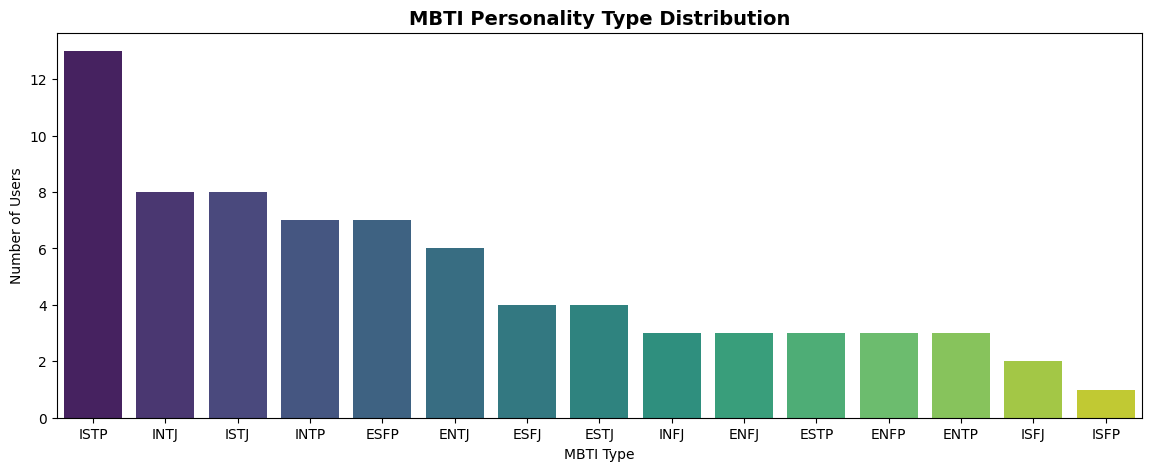

Most common  : ISTP (13 users)
Least common : ISFP (1 users)
Unique types : 15


In [25]:
plt.figure(figsize=(14, 5))
mbti_counts = user['mbti'].value_counts()
sns.barplot(x=mbti_counts.index, y=mbti_counts.values,palette='viridis')
plt.title('MBTI Personality Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('MBTI Type')
plt.ylabel('Number of Users')

plt.show()
print(f"Most common  : {mbti_counts.index[0]} ({mbti_counts.values[0]} users)")
print(f"Least common : {mbti_counts.index[-1]} ({mbti_counts.values[-1]} users)")
print(f"Unique types : {user['mbti'].nunique()}")

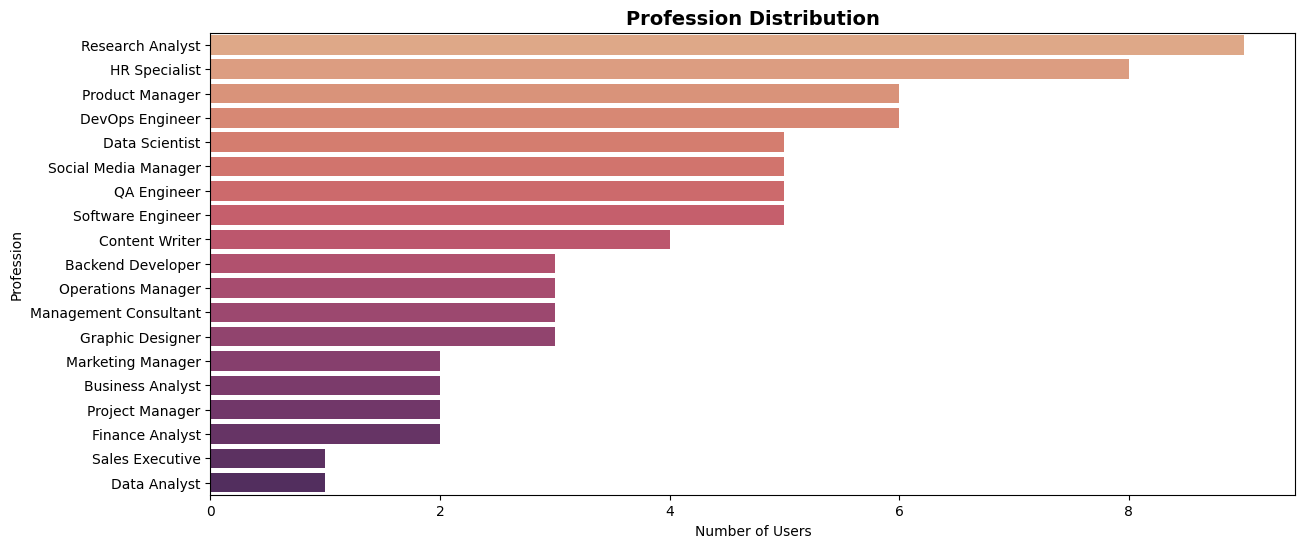

Most common profession : Research Analyst (9 users)
Total unique professions: 19


In [34]:
plt.figure(figsize=(14, 6))
prof_counts = user['profession'].value_counts()
sns.barplot(y=prof_counts.index, x=prof_counts.values, palette='flare')
plt.title('Profession Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of Users')
plt.ylabel('Profession')
plt.show()
print(f"Most common profession : {prof_counts.index[0]} ({prof_counts.values[0]} users)")
print(f"Total unique professions: {user['profession'].nunique()}")

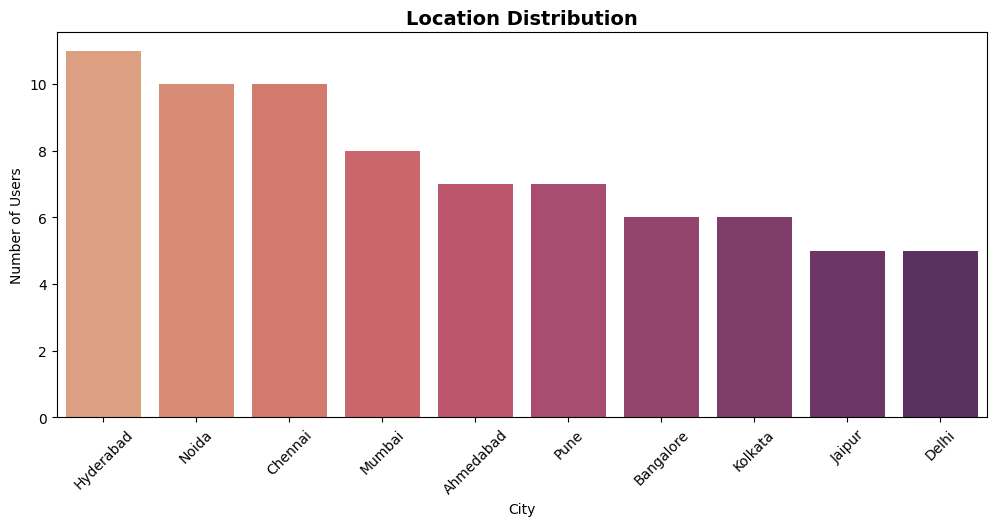

Most users are in : Hyderabad (11 users)
Total cities      : 10


In [35]:
plt.figure(figsize=(12, 5))
loc_counts = user['location'].value_counts()
sns.barplot(x=loc_counts.index, y=loc_counts.values, palette='flare')
plt.title('Location Distribution', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)

plt.show()

print(f"Most users are in : {loc_counts.index[0]} ({loc_counts.values[0]} users)")
print(f"Total cities      : {user['location'].nunique()}")

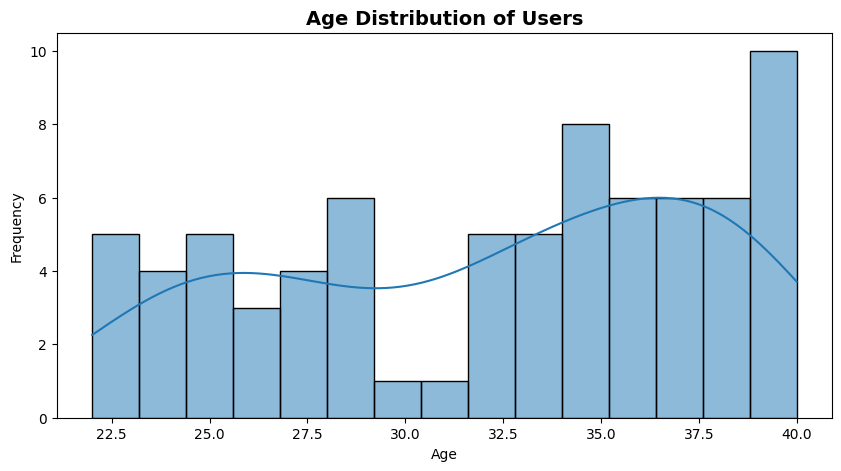

Average age : 32.1 years
Age range   : 22 – 40 years


In [38]:
plt.figure(figsize=(10, 5))
sns.histplot(user['age'], bins=15, kde=True)
plt.title('Age Distribution of Users', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

print(f"Average age : {user['age'].mean():.1f} years")
print(f"Age range   : {user['age'].min()} – {user['age'].max()} years")

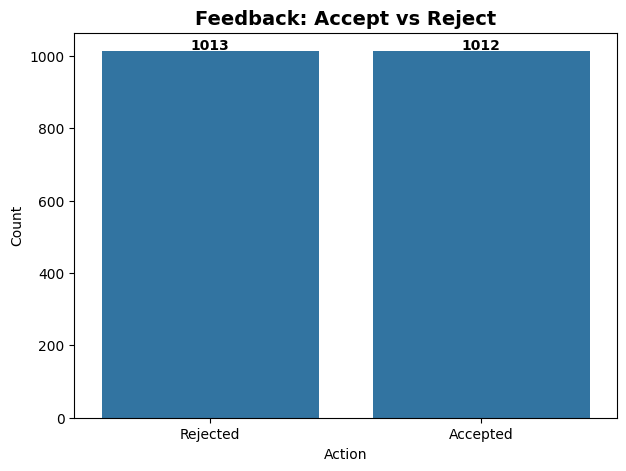

Total records      : 2025
Accepted           : 1012 (50.0%)
Rejected           : 1013 (50.0%)


In [39]:

plt.figure(figsize=(7, 5))
action_counts = feedback['action'].map({1: 'Accepted', 0: 'Rejected'}).value_counts()
bars = sns.barplot(x=action_counts.index, y=action_counts.values)
plt.title('Feedback: Accept vs Reject', fontsize=14, fontweight='bold')
plt.xlabel('Action')
plt.ylabel('Count')
for i, v in enumerate(action_counts.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.show()

accept_rate = (feedback['action'] == 1).mean() * 100
print(f"Total records      : {len(feedback)}")
print(f"Accepted           : {(feedback['action']==1).sum()} ({accept_rate:.1f}%)")
print(f"Rejected           : {(feedback['action']==0).sum()} ({100-accept_rate:.1f}%)")

In [44]:
user.duplicated().sum()


np.int64(0)

In [43]:
feedback.duplicated().sum()

np.int64(0)

In [50]:
print(f"Unique MBTI types         : {user['mbti'].nunique()}")
print(f"Unique professions        : {user['profession'].nunique()}")
print(f"Unique cities             : {user['location'].nunique()}")
print()
print("Feedback class balance (%):")
print(feedback['action'].value_counts(normalize=True).mul(100).round(1))


Unique MBTI types         : 15
Unique professions        : 19
Unique cities             : 10

Feedback class balance (%):
action
0    50.0
1    50.0
Name: proportion, dtype: float64


In [54]:
user['combined_text'] = (user['professional_summary'].fillna('') +
                              ' ' +
                              user['about_me'].fillna(''))
print("Example (first user):")
print(user['combined_text'].iloc[0])

Example (first user):
Experienced HR Specialist specialising in Education, with hands-on expertise in Talent Acquisition, HRIS, Onboarding. Committed to continuous learning and driving measurable impact in fast-paced, innovation-driven environments. I am a natural connector — I love building relationships across departments and industries. My work style is empathetic and outcome-oriented. I enjoy travelling to new cities, attending cultural events, and public speaking.


In [57]:
# ── Steps 2–5: Define and apply the preprocessing function ────────────────
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    #Tokenise and remove stopwords
    tokens = [w for w in text.split() if w not in stop_words]
    #Lemmatise each token
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Apply to every user profile
user['clean_text'] = user['combined_text'].apply(preprocess_text)


print("── BEFORE preprocessing ──────────────────────────────────────────────")
print(user['combined_text'].iloc[0][:300])
print()
print("── AFTER preprocessing ───────────────────────────────────────────────")
print(user['clean_text'].iloc[0][:300])

── BEFORE preprocessing ──────────────────────────────────────────────
Experienced HR Specialist specialising in Education, with hands-on expertise in Talent Acquisition, HRIS, Onboarding. Committed to continuous learning and driving measurable impact in fast-paced, innovation-driven environments. I am a natural connector — I love building relationships across departme

── AFTER preprocessing ───────────────────────────────────────────────
experienced hr specialist specialising education handson expertise talent acquisition hris onboarding committed continuous learning driving measurable impact fastpaced innovationdriven environment natural connector love building relationship across department industry work style empathetic outcomeor


In [59]:
# ── Building TF-IDF matrix ────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=500,    # Keep top 500 most informative terms
    ngram_range=(1, 2),  # Use single words AND two-word phrases (bigrams)
    min_df=2             # Ignore terms that appear in fewer than 2 profiles
)

# Fit on all profiles and transform into a matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(user['clean_text'])

print(" TF-IDF vectorisation complete!")
print(f"Vocabulary size  : {len(tfidf_vectorizer.vocabulary_)} unique terms")
print(f"TF-IDF matrix    : {tfidf_matrix.shape[0]} users × {tfidf_matrix.shape[1]} features")
print()
print("Sample vocabulary (first 20 terms):")
print(list(tfidf_vectorizer.vocabulary_.keys())[:20])

 TF-IDF vectorisation complete!
Vocabulary size  : 500 unique terms
TF-IDF matrix    : 75 users × 500 features

Sample vocabulary (first 20 terms):
['experienced', 'hr', 'specialist', 'specialising', 'education', 'handson', 'expertise', 'talent', 'acquisition', 'hris', 'onboarding', 'committed', 'continuous', 'learning', 'driving', 'measurable', 'impact', 'fastpaced', 'innovationdriven', 'environment']


In [60]:
# ── Compute full N×N cosine similarity matrix ─────────────────────────────
# Entry [i][j] = text similarity between user i and user j
similarity_matrix = cosine_similarity(tfidf_matrix)

print("Cosine similarity matrix computed!")
print(f"Matrix shape : {similarity_matrix.shape}")
print(f"Self-similarity (user 0 vs user 0) : {similarity_matrix[0][0]:.4f}  (always 1.0)")
print(f"Example: User 0 vs User 1           : {similarity_matrix[0][1]:.4f}")

Cosine similarity matrix computed!
Matrix shape : (75, 75)
Self-similarity (user 0 vs user 0) : 1.0000  (always 1.0)
Example: User 0 vs User 1           : 0.0183


In [62]:
# ── Helper function: Text similarity between any two user IDs ──────────────
# Build a fast lookup: user_id → row index
user_id_to_index = {uid: idx for idx, uid in enumerate(user['user_id'])}

def get_text_similarity(user_id_1, user_id_2):
    """Returns cosine text similarity on a 0–100 scale."""
    idx1  = user_id_to_index[user_id_1]
    idx2  = user_id_to_index[user_id_2]
    score = similarity_matrix[idx1][idx2]
    return round(score * 100, 2)

# ── Show examples ──────────────────────────────────────────────────────────
print("Text Similarity Examples:")
print("-" * 55)
for u1, u2 in [('U001', 'U002'), ('U001', 'U003'), ('U002', 'U005')]:
    s  = get_text_similarity(u1, u2)
    n1 = user.loc[user['user_id'] == u1, 'name'].values[0]
    n2 = user.loc[user['user_id'] == u2, 'name'].values[0]
    print(f"  {n1} ({u1})  ↔  {n2} ({u2})  →  {s:.2f} / 100")

Text Similarity Examples:
-------------------------------------------------------
  Advait Verma (U001)  ↔  Arjun Verma (U002)  →  1.83 / 100
  Advait Verma (U001)  ↔  Madhuri Das (U003)  →  1.33 / 100
  Arjun Verma (U002)  ↔  Siddharth Shukla (U005)  →  3.40 / 100


In [63]:
# ── MBTI Compatibility Scoring Function ───────────────────────────────────
def get_mbti_score(mbti1, mbti2):
    if mbti1 == mbti2:
        return 100
    # Count matching letters across the 4 positions
    matches   = sum(1 for a, b in zip(mbti1, mbti2) if a == b)
    score_map = {3: 75, 2: 50, 1: 30, 0: 15}
    return score_map[matches]

# ── Show examples ──────────────────────────────────────────────────────────
print("MBTI Compatibility Score Examples:")
print("-" * 40)
pairs = [('INTJ','INTJ'), ('INTJ','INTP'), ('INTJ','ENTP'),
         ('INTJ','ESFP'), ('ESFP','ESFJ')]
for m1, m2 in pairs:
    print(f"  {m1} ↔ {m2}  →  {get_mbti_score(m1, m2)}")

MBTI Compatibility Score Examples:
----------------------------------------
  INTJ ↔ INTJ  →  100
  INTJ ↔ INTP  →  75
  INTJ ↔ ENTP  →  50
  INTJ ↔ ESFP  →  15
  ESFP ↔ ESFJ  →  75


In [65]:
# ── Location Scoring Function ─────────────────────────────────────────────
def get_location_score(user_id_1, user_id_2):
    """Returns 100 if same city, 50 if different."""
    loc1 = user.loc[user['user_id'] == user_id_1, 'location'].values[0]
    loc2 = user.loc[user['user_id'] == user_id_2, 'location'].values[0]
    return 100 if loc1 == loc2 else 50

# ── Show examples ──────────────────────────────────────────────────────────
print("Location Score Examples:")
print("-" * 50)
for u1, u2 in [('U001', 'U002'), ('U001', 'U003')]:
    l1 = user.loc[user['user_id']==u1, 'location'].values[0]
    l2 = user.loc[user['user_id']==u2, 'location'].values[0]
    print(f"  {u1}({l1}) ↔ {u2}({l2}) → {get_location_score(u1, u2)}")

Location Score Examples:
--------------------------------------------------
  U001(Hyderabad) ↔ U002(Hyderabad) → 100
  U001(Hyderabad) ↔ U003(Ahmedabad) → 50


In [66]:
# ── Hybrid Compatibility Score ────────────────────────────────────────────
W_TEXT     = 0.6   # Weight: text / professional similarity
W_MBTI     = 0.3   # Weight: personality (MBTI) similarity
W_LOCATION = 0.1   # Weight: location proximity

def calculate_compatibility(user_id_1, user_id_2):
    """
    Calculates weighted hybrid compatibility score (0–100).
    """
    text_score = get_text_similarity(user_id_1, user_id_2)
    m1         = user.loc[user['user_id'] == user_id_1, 'mbti'].values[0]
    m2         = user.loc[user['user_id'] == user_id_2, 'mbti'].values[0]
    mbti_score = get_mbti_score(m1, m2)
    loc_score  = get_location_score(user_id_1, user_id_2)

    score = (W_TEXT * text_score + W_MBTI * mbti_score + W_LOCATION * loc_score)
    return round(score, 2)

# ── Demonstrate with worked examples ──────────────────────────────────────
print("=" * 68)
print("Compatibility Score — Step-by-Step Examples")
print("=" * 68)
for u1, u2 in [('U001', 'U002'), ('U001', 'U003'), ('U002', 'U005')]:
    ts = get_text_similarity(u1, u2)
    m1 = user.loc[user['user_id']==u1, 'mbti'].values[0]
    m2 = user.loc[user['user_id']==u2, 'mbti'].values[0]
    ms = get_mbti_score(m1, m2)
    ls = get_location_score(u1, u2)
    cs = calculate_compatibility(u1, u2)
    n1 = user.loc[user['user_id']==u1, 'name'].values[0]
    n2 = user.loc[user['user_id']==u2, 'name'].values[0]
    print(f"\n{n1} ({u1}) ↔ {n2} ({u2})")
    print(f"  Text={ts:.1f}   MBTI={ms}   Location={ls}")
    print(f"  → Score = 0.6×{ts:.1f} + 0.3×{ms} + 0.1×{ls} = {cs:.2f}")

Compatibility Score — Step-by-Step Examples

Advait Verma (U001) ↔ Arjun Verma (U002)
  Text=1.8   MBTI=30   Location=100
  → Score = 0.6×1.8 + 0.3×30 + 0.1×100 = 20.10

Advait Verma (U001) ↔ Madhuri Das (U003)
  Text=1.3   MBTI=30   Location=50
  → Score = 0.6×1.3 + 0.3×30 + 0.1×50 = 14.80

Arjun Verma (U002) ↔ Siddharth Shukla (U005)
  Text=3.4   MBTI=50   Location=50
  → Score = 0.6×3.4 + 0.3×50 + 0.1×50 = 22.04


In [70]:
# ── Recommend Top-N Matches ────────────────────────────────────────────────
def recommend_top_matches(user_id, top_n=5):

    scores = []
    for  _,row in user.iterrows():
        cid = row['user_id']
        if cid == user_id:
            continue
        scores.append({
            'user_id'      : cid,
            'name'         : row['name'],
            'profession'   : row['profession'],
            'location'     : row['location'],
            'mbti'         : row['mbti'],
            'compatibility': calculate_compatibility(user_id, cid)
        })

    results = sorted(scores, key=lambda x: x['compatibility'], reverse=True)
    return pd.DataFrame(results[:top_n])

# ── Show example recommendations ──────────────────────────────────────────
target = 'U001'
tname  = user.loc[user['user_id']==target, 'name'].values[0]
tprof  = user.loc[user['user_id']==target, 'profession'].values[0]
tmbti  = user.loc[user['user_id']==target, 'mbti'].values[0]
tloc   = user.loc[user['user_id']==target, 'location'].values[0]

print(f"Finding top 5 matches for: {tname} ({target})")
print(f"  Profession: {tprof} | MBTI: {tmbti} | Location: {tloc}")
print()
recs = recommend_top_matches(target)
display(recs.reset_index(drop=True))

Finding top 5 matches for: Advait Verma (U001)
  Profession: HR Specialist | MBTI: ESFP | Location: Hyderabad



,user_id,name,profession,location,mbti,compatibility
0,U030,Shaurya Agarwal,Product Manager,Noida,ENFJ,70.85
1,U040,Pallavi Gupta,Management Consultant,Hyderabad,ENTJ,58.52
2,U028,Deepika Pandey,Operations Manager,Delhi,ESTJ,57.05
3,U034,Krishna Pillai,Management Consultant,Pune,ENTP,56.67
4,U005,Siddharth Shukla,HR Specialist,Mumbai,ESFJ,54.84


In [71]:
# ── Compute compatibility for all feedback pairs ──────────────────────────
print("Computing scores for all feedback records... (may take ~30 seconds)")

eval_rows = []
for _, row in feedback.iterrows():
    uid = row['user_id']
    mid = row['matched_user_id']
    if uid in user_id_to_index and mid in user_id_to_index:
        eval_rows.append({
            'action'       : row['action'],
            'compatibility': calculate_compatibility(uid, mid)
        })

eval_df = pd.DataFrame(eval_rows)
print(f"✅ Scored {len(eval_df)} feedback pairs")

accepted_scores = eval_df[eval_df['action'] == 1]['compatibility']
rejected_scores = eval_df[eval_df['action'] == 0]['compatibility']
print(f"\nAverage score — Accepted : {accepted_scores.mean():.2f}")
print(f"Average score — Rejected : {rejected_scores.mean():.2f}")
print(f"Difference               : {accepted_scores.mean() - rejected_scores.mean():.2f}")

Computing scores for all feedback records... (may take ~30 seconds)
✅ Scored 2025 feedback pairs

Average score — Accepted : 31.32
Average score — Rejected : 27.17
Difference               : 4.15


📊  MANN-WHITNEY U TEST
Test statistic : 604417.0
p-value        : 0.0000
✅ SIGNIFICANT (p < 0.05): Accepted scores are meaningfully higher.
   Our recommendation system separates good matches from poor ones.

Cohen's d (effect size): 0.319  → small effect
(Rule of thumb: small=0.2, medium=0.5, large=0.8)


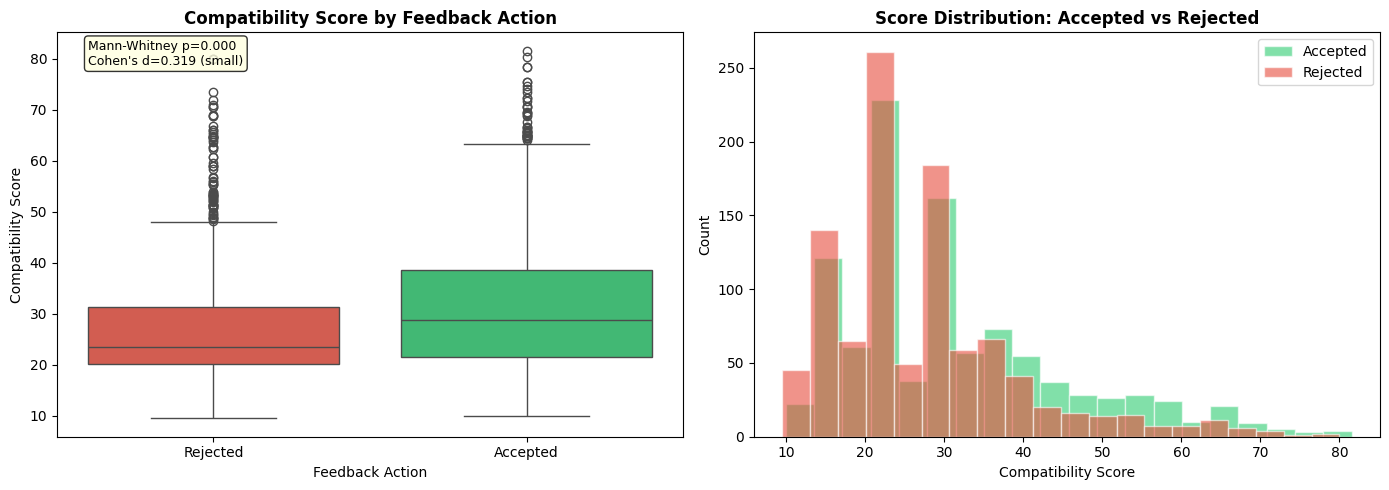

In [72]:
# ── Mann-Whitney U Test — Is the difference statistically significant? ─────
# The Mann-Whitney U test is a non-parametric test (no normality assumption).
# H0: Accepted and Rejected compatibility scores come from the same distribution.
# H1: Accepted scores are significantly HIGHER than Rejected scores.

stat, p_value = mannwhitneyu(accepted_scores, rejected_scores, alternative='greater')

print("=" * 55)
print("📊  MANN-WHITNEY U TEST")
print("=" * 55)
print(f"Test statistic : {stat:.1f}")
print(f"p-value        : {p_value:.4f}")
if p_value < 0.05:
    print("✅ SIGNIFICANT (p < 0.05): Accepted scores are meaningfully higher.")
    print("   Our recommendation system separates good matches from poor ones.")
else:
    print("❌ NOT SIGNIFICANT (p ≥ 0.05): No statistically significant difference.")
    print("   The score gap may be due to random chance, not a real signal.")

# ── Effect size: Cohen's d ─────────────────────────────────────────────────
def cohens_d(a, b):
    pooled_std = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled_std

d = cohens_d(accepted_scores, rejected_scores)
magnitude = 'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'
print(f"\nCohen's d (effect size): {d:.3f}  → {magnitude} effect")
print("(Rule of thumb: small=0.2, medium=0.5, large=0.8)")

# ── Visualise score distributions ─────────────────────────────────────────
eval_df['label'] = eval_df['action'].map({1: 'Accepted', 0: 'Rejected'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='label', y='compatibility', data=eval_df,
            palette={'Accepted': '#2ecc71', 'Rejected': '#e74c3c'}, ax=axes[0])
axes[0].set_title('Compatibility Score by Feedback Action', fontweight='bold')
axes[0].set_xlabel('Feedback Action')
axes[0].set_ylabel('Compatibility Score')
axes[0].annotate(f'Mann-Whitney p={p_value:.3f}\nCohen\'s d={d:.3f} ({magnitude})',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

for action, color, label in [(1,'#2ecc71','Accepted'),(0,'#e74c3c','Rejected')]:
    axes[1].hist(eval_df[eval_df['action']==action]['compatibility'],
                 bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
axes[1].set_title('Score Distribution: Accepted vs Rejected', fontweight='bold')
axes[1].set_xlabel('Compatibility Score')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [76]:
# ── Build feature matrix from all feedback pairs ──────────────────────────
print("Building feature matrix from feedback data...")

feature_rows = []
for _, row in feedback.iterrows():
    uid    = row['user_id']
    mid    = row['matched_user_id']
    action = row['action']
    if uid in user_id_to_index and mid in user_id_to_index:
        idx1 = user_id_to_index[uid]
        idx2 = user_id_to_index[mid]
        text_sim = float(similarity_matrix[idx1][idx2] * 100)
        m1 = user.loc[user['user_id'] == uid,  'mbti'].values[0]
        m2 = user.loc[user['user_id'] == mid, 'mbti'].values[0]
        mbti_sim = float(get_mbti_score(m1, m2))
        loc_sim  = float(get_location_score(uid, mid))
        feature_rows.append({
            'user_id'        : uid,           # kept for user-level split
            'text_similarity': text_sim,
            'mbti_score'     : mbti_sim,
            'location_score' : loc_sim,
            'action'         : action
        })

features_df = pd.DataFrame(feature_rows)
print(f"✅ Feature matrix: {features_df.shape[0]} rows × {features_df.shape[1]} columns")
display(features_df.drop(columns=['user_id']).head())

Building feature matrix from feedback data...
✅ Feature matrix: 2025 rows × 5 columns


,text_similarity,mbti_score,location_score,action
0,2.524672,15.0,100.0,0
1,1.426830,75.0,100.0,0
2,38.075682,30.0,50.0,0
3,1.826573,30.0,100.0,1
4,84.747421,50.0,50.0,0


In [77]:
# ── User-Level Train-Test Split ───────────────────────────────────────────
# WHY USER-LEVEL SPLIT?
# There are only 75 users. A random row-level split puts the same user's
# interactions in both train AND test — the model sees each user's preferences
# during training and is then "tested" on the same users. This is data leakage.
# Solution: hold out entire users for testing.

all_users         = features_df['user_id'].unique()
train_users, test_users = train_test_split(all_users, test_size=0.2, random_state=42)

train_df = features_df[features_df['user_id'].isin(train_users)]
test_df  = features_df[features_df['user_id'].isin(test_users)]

FEATURE_COLS = ['text_similarity', 'mbti_score', 'location_score']
X_train = train_df[FEATURE_COLS]
y_train = train_df['action']
X_test  = test_df[FEATURE_COLS]
y_test  = test_df['action']

# Verify no leakage
overlap = set(train_users) & set(test_users)
print("=" * 55)
print("📋  TRAIN / TEST SPLIT SUMMARY")
print("=" * 55)
print(f"Total users              : {len(all_users)}")
print(f"Training users           : {len(train_users)}")
print(f"Test users               : {len(test_users)}")
print(f"Users in BOTH (leakage)  : {len(overlap)}  ← should be 0")
print()
print(f"Training feedback rows   : {len(X_train)}")
print(f"Test feedback rows       : {len(X_test)}")
print(f"Train class dist         : {y_train.value_counts().to_dict()}")
print(f"Test class dist          : {y_test.value_counts().to_dict()}")

📋  TRAIN / TEST SPLIT SUMMARY
Total users              : 75
Training users           : 60
Test users               : 15
Users in BOTH (leakage)  : 0  ← should be 0

Training feedback rows   : 1620
Test feedback rows       : 405
Train class dist         : {1: 819, 0: 801}
Test class dist          : {0: 212, 1: 193}


In [78]:
# ── Step 1: Majority-Class Baseline ──────────────────────────────────────
# A DummyClassifier that always predicts the majority class (Reject).
# Our model MUST beat this to be considered useful.

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_dummy   = dummy.predict(X_test)
baseline_acc = accuracy_score(y_test, y_dummy)

print("=" * 60)
print("📏  MAJORITY-CLASS BASELINE (always predict 'Reject')")
print("=" * 60)
print(f"Baseline Accuracy : {baseline_acc * 100:.2f}%")
print(f"(A useful model MUST score above {baseline_acc * 100:.1f}%)")

# ── Step 2: Build Pipeline — Scaler + Balanced Logistic Regression ─────────
# StandardScaler: rescales each feature to mean=0, std=1
#   → prevents features with larger ranges from dominating the model
# class_weight='balanced': upweights the minority class (Accept)
#   → prevents the model from ignoring Accepts

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(class_weight='balanced',
                                   max_iter=1000,
                                   random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred      = pipeline.predict(X_test)
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]  # probability of Accept

# ── Step 3: Compute All Metrics ────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print()
print("=" * 60)
print("🤖  LOGISTIC REGRESSION PIPELINE — EVALUATION")
print("=" * 60)
print(f"Accuracy         : {acc  * 100:.2f}%  (Baseline: {baseline_acc*100:.1f}%)")
print(f"ROC-AUC Score    : {auc  * 100:.2f}%")
print(f"Model vs Baseline: {'✅ beats baseline' if acc > baseline_acc else '❌ below baseline'}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Accepted']))

📏  MAJORITY-CLASS BASELINE (always predict 'Reject')
Baseline Accuracy : 47.65%
(A useful model MUST score above 47.7%)

🤖  LOGISTIC REGRESSION PIPELINE — EVALUATION
Accuracy         : 58.27%  (Baseline: 47.7%)
ROC-AUC Score    : 64.73%
Model vs Baseline: ✅ beats baseline

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.58      0.77      0.66       212
    Accepted       0.60      0.37      0.46       193

    accuracy                           0.58       405
   macro avg       0.59      0.57      0.56       405
weighted avg       0.59      0.58      0.56       405



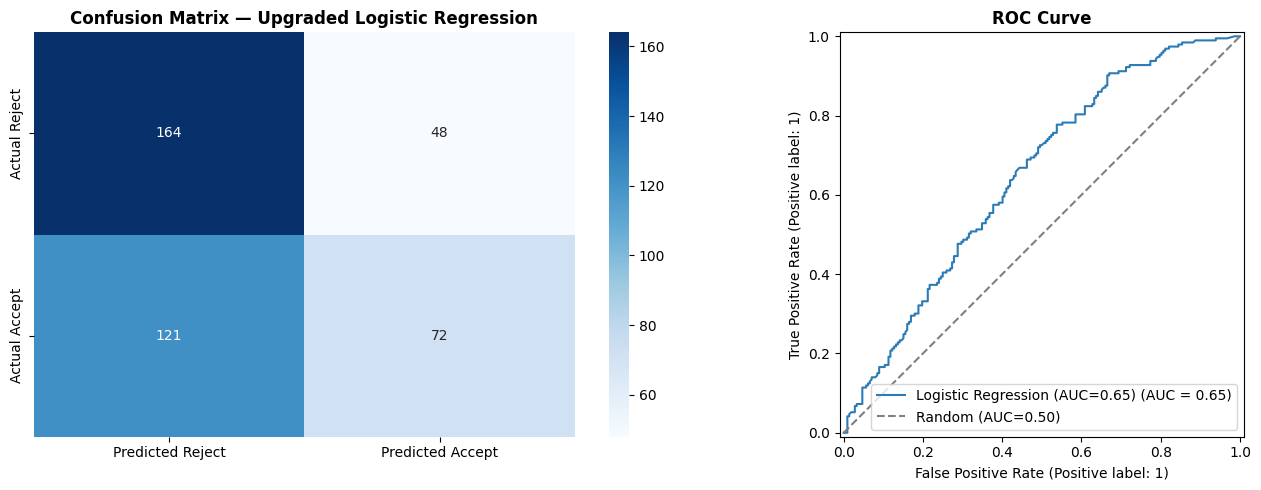

Reading the Confusion Matrix:
  True Negatives  (TN) = 164  → Correctly predicted Rejected
  False Positives (FP) = 48  → Predicted Accept, was actually Reject
  False Negatives (FN) = 121  → Predicted Reject, was actually Accept
  True Positives  (TP) = 72  → Correctly predicted Accepted

ROC-AUC Interpretation:
  AUC = 0.647
    Fair discrimination — model has some signal but limited


In [81]:
# ── Confusion Matrix + ROC Curve ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Reject', 'Predicted Accept'],
            yticklabels=['Actual Reject', 'Actual Accept'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Upgraded Logistic Regression',
                  fontsize=12, fontweight='bold')

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_prob,
                                  name=f'Logistic Regression (AUC={auc:.2f})',
                                  ax=axes[1], color='#2c7bb6')
axes[1].plot([0,1],[0,1],'--', color='grey', label='Random (AUC=0.50)')
axes[1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("Reading the Confusion Matrix:")
print(f"  True Negatives  (TN) = {tn}  → Correctly predicted Rejected")
print(f"  False Positives (FP) = {fp}  → Predicted Accept, was actually Reject")
print(f"  False Negatives (FN) = {fn}  → Predicted Reject, was actually Accept")
print(f"  True Positives  (TP) = {tp}  → Correctly predicted Accepted")
print()
print("ROC-AUC Interpretation:")
print(f"  AUC = {auc:.3f}")
if auc >= 0.70:
    print("  Good discrimination — model meaningfully separates Accept from Reject")
elif auc >= 0.60:
    print("    Fair discrimination — model has some signal but limited")
else:
    print("  Poor discrimination — model is close to random guessing")
    print("     This is an honest finding: our 3 features have limited predictive power.")
    print("     See Section 15 for improvements.")

  FEATURE vs ACCEPTANCE — CORRELATION ANALYSIS
Feature                        r     p-value    Significant?
------------------------------------------------------------
text_similarity          +0.1521      0.0000    Yes (p<0.05)
mbti_score               +0.0475      0.0326    Yes (p<0.05)
location_score           +0.0476      0.0323    Yes (p<0.05)

Interpretation:
  r > 0 → higher feature score associated with more Accepts
  r < 0 → higher feature score associated with more Rejects
  p < 0.05 → the relationship is statistically significant


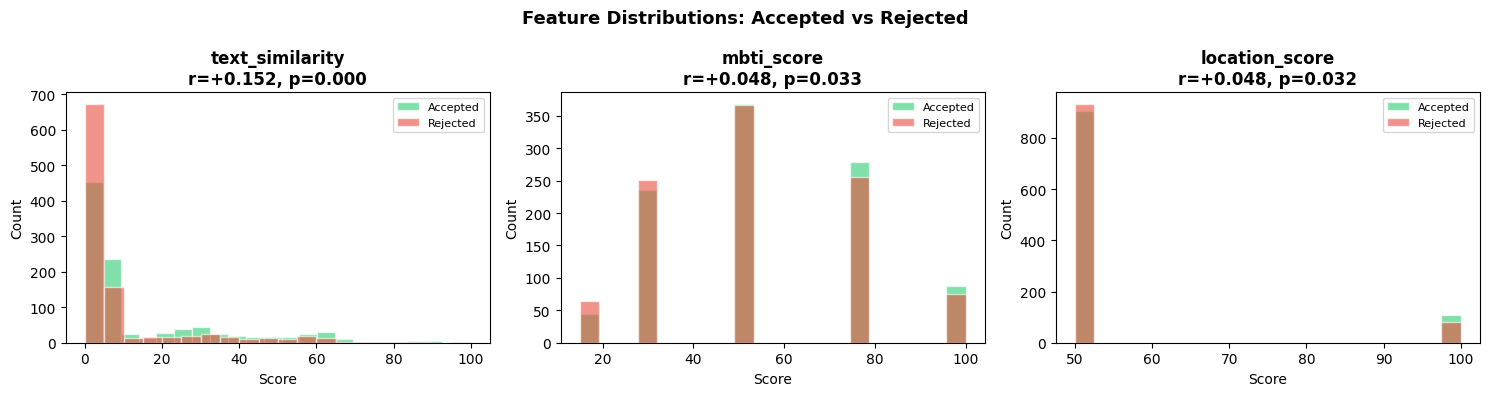


Key Finding:
If p > 0.05 for all features, the model has limited predictive signal.
This is an HONEST result — it means our features need improvement,
not that we should hide the analysis.


In [84]:
# ── Point-Biserial Correlation: each feature vs Accept/Reject ─────────────
X_all = features_df[FEATURE_COLS]
y_all = features_df['action']

print("=" * 65)
print("  FEATURE vs ACCEPTANCE — CORRELATION ANALYSIS")
print("=" * 65)
print(f"{'Feature':<22}  {'r':>8}  {'p-value':>10}  {'Significant?':>14}")
print("-" * 60)
for col in FEATURE_COLS:
    r, p = pointbiserialr(y_all, X_all[col])
    sig  = 'Yes (p<0.05)' if p < 0.05 else ' No'
    print(f"{col:<22}  {r:>+8.4f}  {p:>10.4f}  {sig:>14}")

print()
print("Interpretation:")
print("  r > 0 → higher feature score associated with more Accepts")
print("  r < 0 → higher feature score associated with more Rejects")
print("  p < 0.05 → the relationship is statistically significant")

# ── Visualise correlations ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(FEATURE_COLS):
    r, p = pointbiserialr(y_all, X_all[col])
    for action, color, label in [(1,'#2ecc71','Accepted'),(0,'#e74c3c','Rejected')]:
        axes[i].hist(X_all[y_all==action][col], bins=20,
                     alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(f'{col}\nr={r:+.3f}, p={p:.3f}', fontweight='bold')
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions: Accepted vs Rejected', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("Key Finding:")
print("If p > 0.05 for all features, the model has limited predictive signal.")
print("This is an HONEST result — it means our features need improvement,")
print("not that we should hide the analysis.")

  5-FOLD STRATIFIED CROSS-VALIDATION RESULTS
  Accuracy              :  56.1% ±  1.3%   ███████████
  ROC-AUC               :  59.4% ±  2.0%   ███████████
  F1-Score (Accept)     :  47.0% ±  2.0%   █████████
  Precision (Accept)    :  59.3% ±  1.8%   ███████████
  Recall (Accept)       :  38.9% ±  2.3%   ███████

  Majority-class baseline  : 50.0%  (accuracy if always predict Reject)



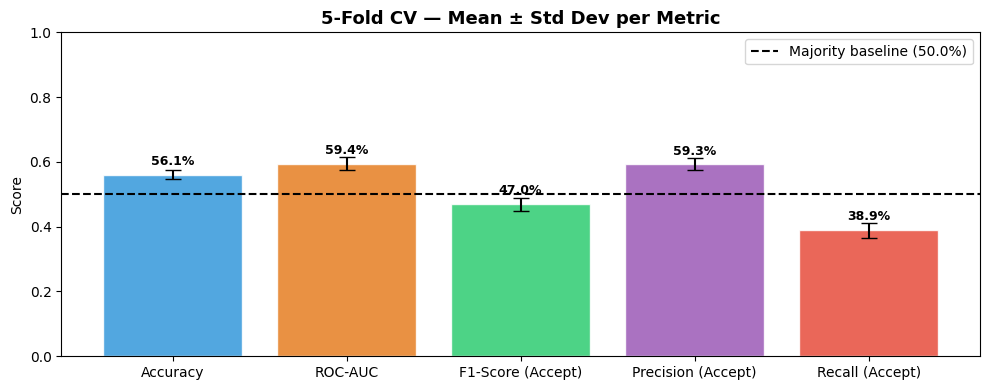

Interpretation:
  Large std dev (±5%+) means performance varies heavily by which users
  are in train vs test — a sign that 75 users is too few to train stably.


In [86]:
# ── 5-Fold Stratified Cross-Validation ────────────────────────────────────
X_all_arr = features_df[FEATURE_COLS].values
y_all_arr = features_df['action'].values

# Build the same pipeline for CV
cv_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(class_weight='balanced',
                                   max_iter=1000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 60)
print("  5-FOLD STRATIFIED CROSS-VALIDATION RESULTS")
print("=" * 60)

metrics = {
    'accuracy' : 'Accuracy',
    'roc_auc'  : 'ROC-AUC',
    'f1'       : 'F1-Score (Accept)',
    'precision': 'Precision (Accept)',
    'recall'   : 'Recall (Accept)',
}

cv_results = {}
for metric, label in metrics.items():
    scores = cross_val_score(cv_pipeline, X_all_arr, y_all_arr,
                             cv=cv, scoring=metric)
    cv_results[metric] = scores
    bar = '█' * int(scores.mean() * 20)
    print(f"  {label:<22}: {scores.mean()*100:5.1f}% ± {scores.std()*100:4.1f}%   {bar}")

print()
print(f"  Majority-class baseline  : {y_all_arr.mean()*0 + (1 - y_all_arr.mean())*100:.1f}%  (accuracy if always predict Reject)")
print()

# ── Visualise CV score distributions ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
labels  = [metrics[m] for m in metrics]
means   = [cv_results[m].mean() for m in metrics]
stds    = [cv_results[m].std()  for m in metrics]
colors  = ['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c']

bars = ax.bar(labels, means, yerr=stds, capsize=6,
              color=colors, edgecolor='white', alpha=0.85)
ax.axhline(1 - y_all_arr.mean(), color='black', linestyle='--',
           linewidth=1.5, label=f'Majority baseline ({(1-y_all_arr.mean())*100:.1f}%)')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('5-Fold CV — Mean ± Std Dev per Metric', fontsize=13, fontweight='bold')
ax.legend()
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{mean*100:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Large std dev (±5%+) means performance varies heavily by which users")
print("  are in train vs test — a sign that 75 users is too few to train stably.")

WEIGHT COMPARISON: Assumed vs ML-Learned (scaled coefficients)
Feature                   Raw coef     Direction   Assumed   Learned %
--------------------------------------------------------------------
text_similarity            +0.3265      ↑ Accept      0.60      0.7942
mbti_score                 +0.0318      ↑ Accept      0.30      0.0774
location_score             +0.0528      ↑ Accept      0.10      0.1284


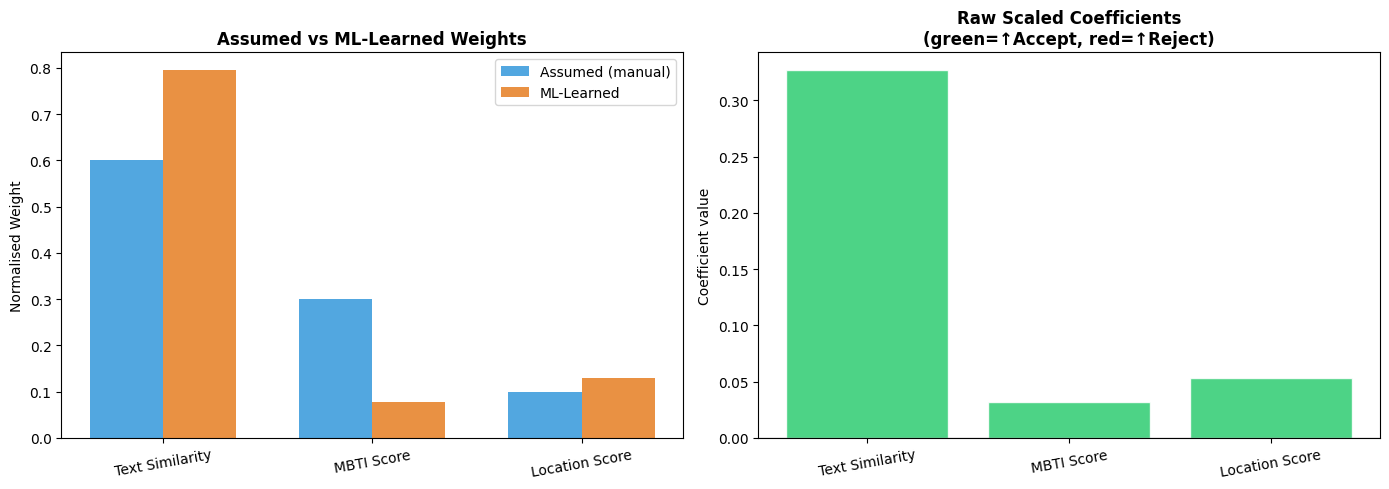


AUC achieved: 0.647
 AUC is reasonable — coefficient interpretation is meaningful.


In [88]:
# ── Extract scaled coefficients from the pipeline ─────────────────────────
# pipeline['lr'] gives us the Logistic Regression step
# Because StandardScaler was applied inside the pipeline, these coefficients
# are directly comparable in magnitude.

lr_step      = pipeline.named_steps['lr']
coef_scaled  = lr_step.coef_[0]   # one coefficient per feature
feature_names= FEATURE_COLS

print("=" * 62)
print("WEIGHT COMPARISON: Assumed vs ML-Learned (scaled coefficients)")
print("=" * 62)
assumed = [0.6, 0.3, 0.1]

# Normalise absolute scaled coefficients to sum=1 for fair comparison
abs_coef   = np.abs(coef_scaled)
normalised = abs_coef / abs_coef.sum()

print(f"{'Feature':<22}  {'Raw coef':>10}  {'Direction':>12}  {'Assumed':>8}  {'Learned %':>10}")
print("-" * 68)
for name, coef, norm, assum in zip(feature_names, coef_scaled, normalised, assumed):
    direction = '↑ Accept' if coef > 0 else '↓ Reject'
    print(f"{name:<22}  {coef:>+10.4f}  {direction:>12}  {assum:>8.2f}  {norm:>10.4f}")

# ── Bar chart comparison ───────────────────────────────────────────────────
x      = np.arange(len(feature_names))
width  = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Assumed vs Learned weights
axes[0].bar(x - width/2, assumed,    width, label='Assumed (manual)', color='#3498db', alpha=0.85)
axes[0].bar(x + width/2, normalised, width, label='ML-Learned',       color='#e67e22', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Text Similarity', 'MBTI Score', 'Location Score'], rotation=10)
axes[0].set_ylabel('Normalised Weight')
axes[0].set_title('Assumed vs ML-Learned Weights', fontweight='bold')
axes[0].legend()

# Panel 2: Raw signed coefficients (direction matters)
colors_dir = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_scaled]
axes[1].bar(feature_names, coef_scaled, color=colors_dir, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Raw Scaled Coefficients\n(green=↑Accept, red=↑Reject)', fontweight='bold')
axes[1].set_ylabel('Coefficient value')
axes[1].set_xticklabels(['Text Similarity', 'MBTI Score', 'Location Score'], rotation=10)

plt.tight_layout()
plt.show()

print()
print("AUC achieved:", round(auc, 3))
if auc < 0.60:
    print(" AUC < 0.60 — interpret coefficients cautiously.")
    print("   The features have limited predictive power on this dataset.")
    print("   The coefficient pattern is directionally interesting but not reliable.")
else:
    print(" AUC is reasonable — coefficient interpretation is meaningful.")

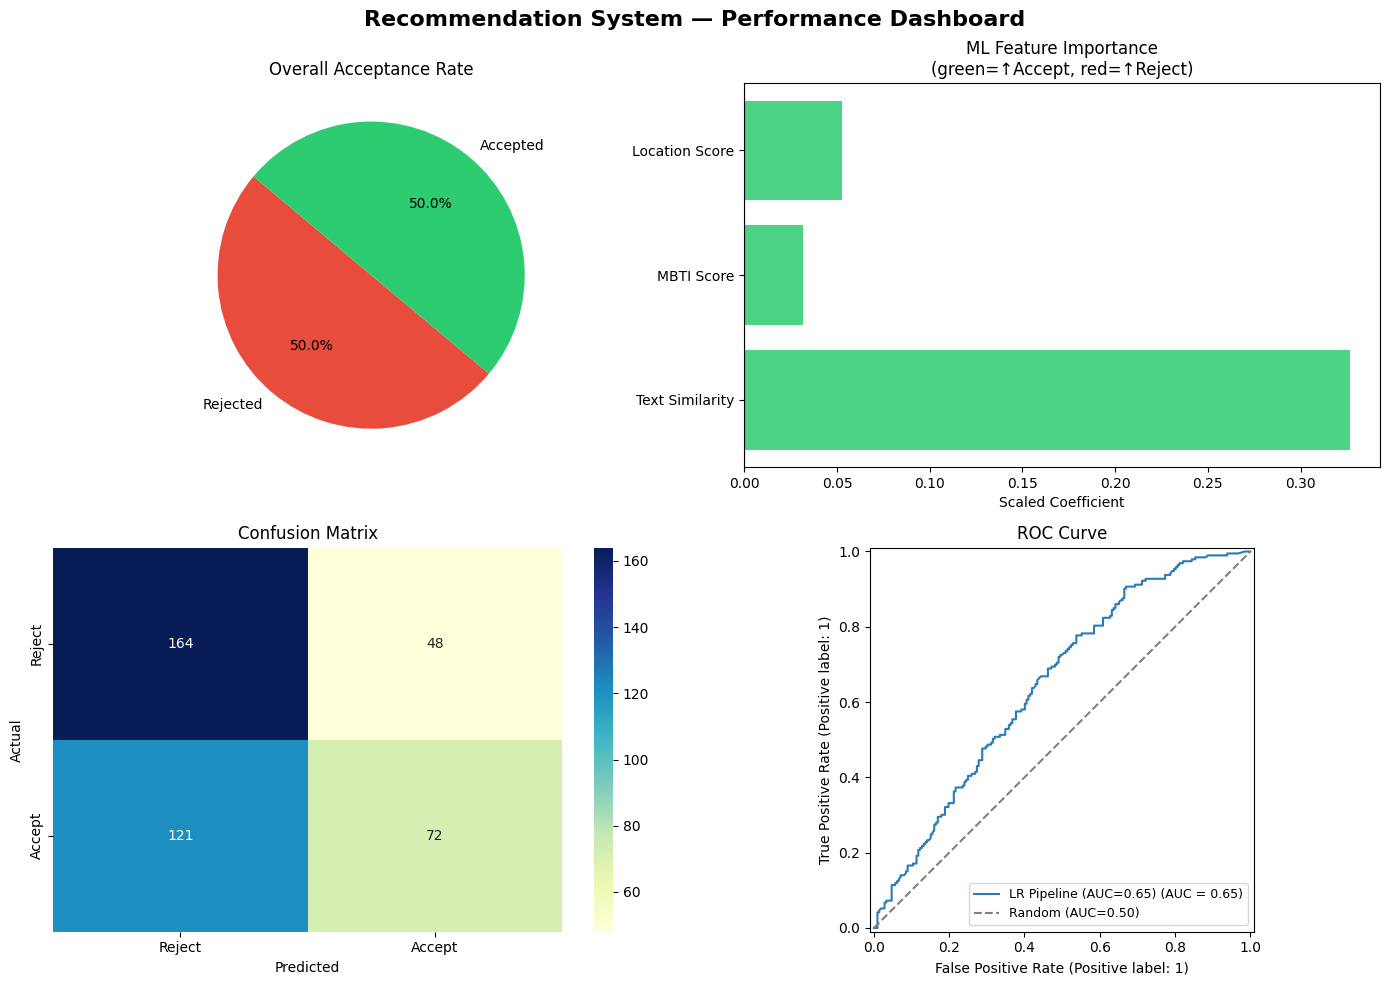

In [91]:
# ── 4-panel performance dashboard ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Recommendation System — Performance Dashboard',
             fontsize=16, fontweight='bold')

# Panel 1: Acceptance Rate (Pie)
action_counts = feedback['action'].value_counts()
axes[0,0].pie(action_counts.values,
              labels=['Rejected', 'Accepted'],
              autopct='%1.1f%%',
              colors=['#e74c3c', '#2ecc71'],
              startangle=140)
axes[0,0].set_title('Overall Acceptance Rate')

# Panel 2: Feature Importance (scaled coefficients from pipeline)
lr_step_dash = pipeline.named_steps['lr']
coef_dash    = lr_step_dash.coef_[0]
colors_dash  = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_dash]
axes[0,1].barh(['Text Similarity', 'MBTI Score', 'Location Score'],
               coef_dash, color=colors_dash, alpha=0.85)
axes[0,1].axvline(0, color='black', linewidth=0.8)
axes[0,1].set_xlabel('Scaled Coefficient')
axes[0,1].set_title('ML Feature Importance\n(green=↑Accept, red=↑Reject)')

# Panel 3: Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Reject','Accept'],
            yticklabels=['Reject','Accept'], ax=axes[1,0])
axes[1,0].set_title('Confusion Matrix')
axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('Actual')

# Panel 4: ROC Curve
RocCurveDisplay.from_predictions(y_test, y_pred_prob,
                                  name=f'LR Pipeline (AUC={auc:.2f})',
                                  ax=axes[1,1], color='#2c7bb6')
axes[1,1].plot([0,1],[0,1],'--',color='grey',label='Random (AUC=0.50)')
axes[1,1].set_title('ROC Curve')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.show()


In [95]:
# ── Command-Line Recommendation Interface ─────────────────────────────────
def display_profile(user_id):
    row = user.loc[user['user_id'] == user_id].iloc[0]
    print(f"  User ID    : {row['user_id']}")
    print(f"  Name       : {row['name']}")
    print(f"  Age        : {row['age']}")
    print(f"  Location   : {row['location']}")
    print(f"  Profession : {row['profession']}")
    print(f"  MBTI       : {row['mbti']}")

def run_recommendation_ui(user_id):
    if user_id not in user['user_id'].values:
        print(f"❌ User '{user_id}' not found. Valid IDs: U001 – U{len(user):03d}")
        return

    print("\n" + "=" * 62)
    print("       INTELLIGENT PROFILE RECOMMENDATION SYSTEM")
    print("=" * 62)
    print("\n YOUR PROFILE:")
    display_profile(user_id)
    print("\n" + "-" * 62)
    print("       YOUR TOP 5 RECOMMENDED MATCHES")
    print("-" * 62)

    recs = recommend_top_matches(user_id, top_n=5)
    for rank, (_, rec) in enumerate(recs.iterrows(), 1):
        print(f"\n  [{rank}] {rec['name']} ({rec['user_id']})")
        print(f"       Profession  : {rec['profession']}")
        print(f"       Location    : {rec['location']}")
        print(f"       MBTI        : {rec['mbti']}")
        print(f"        Compatibility Score : {rec['compatibility']:.1f} / 100")

    print("\n" + "=" * 62)

# ── Try different user IDs ─────────────────────────────────────────────────
run_recommendation_ui('U001')
print()
run_recommendation_ui('U010')


       INTELLIGENT PROFILE RECOMMENDATION SYSTEM

 YOUR PROFILE:
  User ID    : U001
  Name       : Advait Verma
  Age        : 25
  Location   : Hyderabad
  Profession : HR Specialist
  MBTI       : ESFP

--------------------------------------------------------------
       YOUR TOP 5 RECOMMENDED MATCHES
--------------------------------------------------------------

  [1] Shaurya Agarwal (U030)
       Profession  : Product Manager
       Location    : Noida
       MBTI        : ENFJ
        Compatibility Score : 70.8 / 100

  [2] Pallavi Gupta (U040)
       Profession  : Management Consultant
       Location    : Hyderabad
       MBTI        : ENTJ
        Compatibility Score : 58.5 / 100

  [3] Deepika Pandey (U028)
       Profession  : Operations Manager
       Location    : Delhi
       MBTI        : ESTJ
        Compatibility Score : 57.0 / 100

  [4] Krishna Pillai (U034)
       Profession  : Management Consultant
       Location    : Pune
       MBTI        : ENTP
        Comp